In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
# =====================================================
# Project Paths
# =====================================================

PROJECT_ROOT = Path.cwd().parent.parent

PROCESSED_DATA_FOLDER = PROJECT_ROOT / "data" / "processed"

CHARTS_FOLDER = PROJECT_ROOT / "reports" / "charts"

CHARTS_FOLDER.mkdir(parents=True, exist_ok=True)

In [3]:
from pathlib import Path

RAW_DATA_FOLDER = Path("../../data/raw")

print(RAW_DATA_FOLDER.resolve())
print(RAW_DATA_FOLDER.exists())

C:\Users\venka\OneDrive\Desktop\CricIntel-AI\data\raw
True


In [4]:
from pathlib import Path

RAW_DATA_FOLDER = Path("../../data/raw")

matches = pd.read_csv(RAW_DATA_FOLDER / "Matches.csv")
customers = pd.read_csv(RAW_DATA_FOLDER / "Customers.csv")
ticket_sales = pd.read_csv(RAW_DATA_FOLDER / "Ticket_Sales.csv")

In [5]:
matches = pd.read_csv(RAW_DATA_FOLDER / "Matches.csv")
customers = pd.read_csv(RAW_DATA_FOLDER / "Customers.csv")
ticket_sales = pd.read_csv(RAW_DATA_FOLDER / "Ticket_Sales.csv")

print(matches.shape)
print(customers.shape)
print(ticket_sales.shape)

(74, 12)
(12000, 15)
(150000, 10)


In [6]:
from pathlib import Path

for file in Path(".").rglob("*.csv"):
    print(file)

In [7]:
from pathlib import Path

RAW_DATA_FOLDER = Path("../../data/raw")

In [8]:
def create_bar_chart(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    rotation=45
):

    plt.figure(figsize=(10,6))

    data.plot(
        kind="bar",
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.xticks(rotation=rotation)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"{filename} saved successfully.")

In [9]:
def create_pie_chart(
    data,
    title,
    filename,
    figsize=(8,8)
):

    plt.figure(figsize=figsize)

    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [10]:
def create_line_chart(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    figsize=(12,6)
):

    plt.figure(figsize=figsize)

    plt.plot(
        data.index,
        data.values,
        marker="o",
        linewidth=2
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [11]:
def create_histogram(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    bins=15,
    figsize=(10,6)
):

    plt.figure(figsize=figsize)

    plt.hist(
        data,
        bins=bins,
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [12]:
def create_histogram(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    bins=15,
    figsize=(10,6)
):

    plt.figure(figsize=figsize)

    plt.hist(
        data,
        bins=bins,
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

# Bivariate & Multivariate Analysis

# Module 1 : Revenue Analysis

In [13]:
sales_data = (
    ticket_sales
    .merge(matches, on="Match_ID", how="left")
    .merge(customers, on="Customer_ID", how="left")
)

display(sales_data.head())

,Ticket_ID,Customer_ID,Match_ID,Booking_Date,Seat_Category,Ticket_Price,Quantity,Total_Amount,Payment_Method,Booking_Status,Match_Date,Season,Home_Team,Away_Team,Venue,City_x,Match_Type,Stadium_Capacity,VIP_Capacity,Premium_Capacity,Economy_Capacity,First_Name,Last_Name,Gender,Age,Date_of_Birth,City_y,State,Favorite_Team,Occupation,Annual_Income,Loyalty_Tier,Email,Phone,Registration_Date
0,T000001,C10477,M009,2026-03-28,Economy,800,1,800,UPI,Confirmed,2026-04-05,IPL 2026,SRH,RR,Rajiv Gandhi International Stadium,Hyderabad,League,55000,3000,12000,40000,Netra,Narang,Female,33,1993-04-02,Bengaluru,Karnataka,KKR,Nurse,329967,Bronze,netra.narang790@outlook.com,8904618696,2024-09-12
1,T000002,C11088,M039,2026-03-18,Premium,2000,1,2000,UPI,Confirmed,2026-05-05,IPL 2026,RCB,DC,M. Chinnaswamy Stadium,Bengaluru,League,40000,2500,9000,28500,Peter,Nath,Male,55,1971-11-12,Mohali,Punjab,RCB,Police Officer,467400,Silver,peter.nath759@outlook.com,7963916621,2024-06-24
2,T000003,C03583,M029,2026-04-10,Economy,800,1,800,UPI,Confirmed,2026-04-25,IPL 2026,KKR,SRH,Eden Gardens,Kolkata,League,68000,3500,15000,49500,Sanya,Grover,Female,19,2007-11-26,Bengaluru,Karnataka,SRH,Police Officer,516254,Silver,sanya.grover701@hotmail.com,6785351562,2025-03-04
3,T000004,C08929,M002,2026-03-02,Economy,800,2,1600,Debit Card,Confirmed,2026-03-29,IPL 2026,MI,RCB,Wankhede Stadium,Mumbai,League,33000,1800,7000,24200,Wriddhish,Rajagopalan,Male,36,1990-08-18,Hyderabad,Telangana,MI,Chartered Accountant,2192494,Silver,wriddhish.rajagopalan511@outlook.com,7430869547,2024-11-30
4,T000005,C02616,M036,2026-03-18,Economy,800,1,800,UPI,Confirmed,2026-05-02,IPL 2026,GT,RR,Narendra Modi Stadium,Ahmedabad,League,132000,6000,26000,100000,Saumya,Tailor,Female,52,1974-10-10,Lucknow,Uttar Pradesh,RR,Police Officer,490251,Silver,saumya.tailor783@hotmail.com,7739250144,2025-01-22


In [14]:
print(sales_data.shape)

display(sales_data.columns)

(150000, 35)


Index(['Ticket_ID', 'Customer_ID', 'Match_ID', 'Booking_Date', 'Seat_Category', 'Ticket_Price', 'Quantity', 'Total_Amount', 'Payment_Method', 'Booking_Status', 'Match_Date', 'Season', 'Home_Team', 'Away_Team', 'Venue', 'City_x', 'Match_Type', 'Stadium_Capacity', 'VIP_Capacity', 'Premium_Capacity', 'Economy_Capacity', 'First_Name', 'Last_Name', 'Gender', 'Age', 'Date_of_Birth', 'City_y', 'State', 'Favorite_Team', 'Occupation', 'Annual_Income', 'Loyalty_Tier', 'Email', 'Phone', 'Registration_Date'], dtype='object')

## Business Question

Which seat category generates the highest revenue?

In [30]:
seat_revenue = (
    sales_data
    .groupby("Seat_Category")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(seat_revenue)

Seat_Category
Premium    153212000
VIP        128860000
Economy    121964000
Name: Total_Amount, dtype: int64

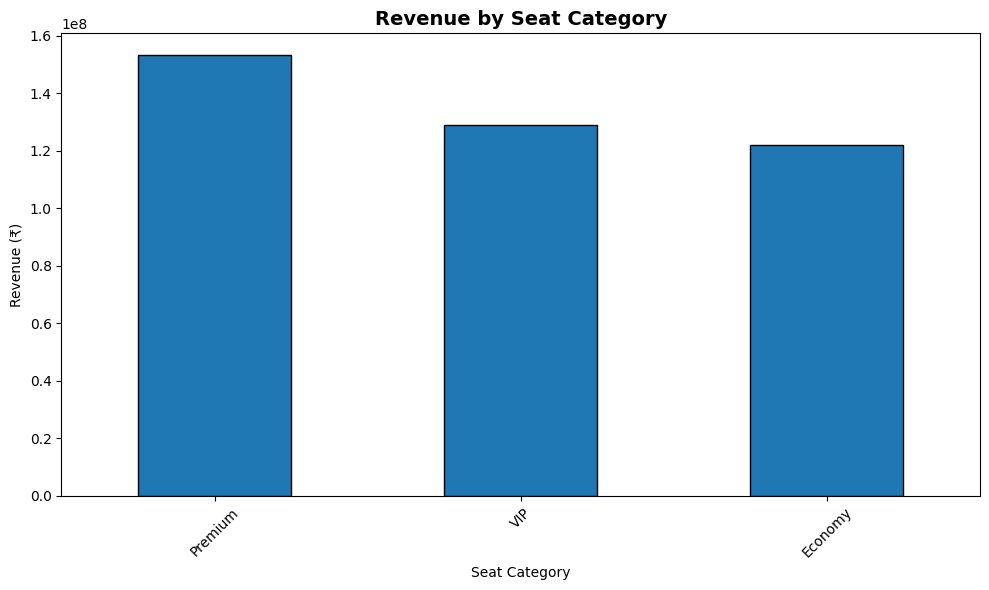

revenue_by_seat_category.png saved successfully.


In [16]:
create_bar_chart(
    data=seat_revenue,
    title="Revenue by Seat Category",
    xlabel="Seat Category",
    ylabel="Revenue (₹)",
    filename="revenue_by_seat_category.png"
)

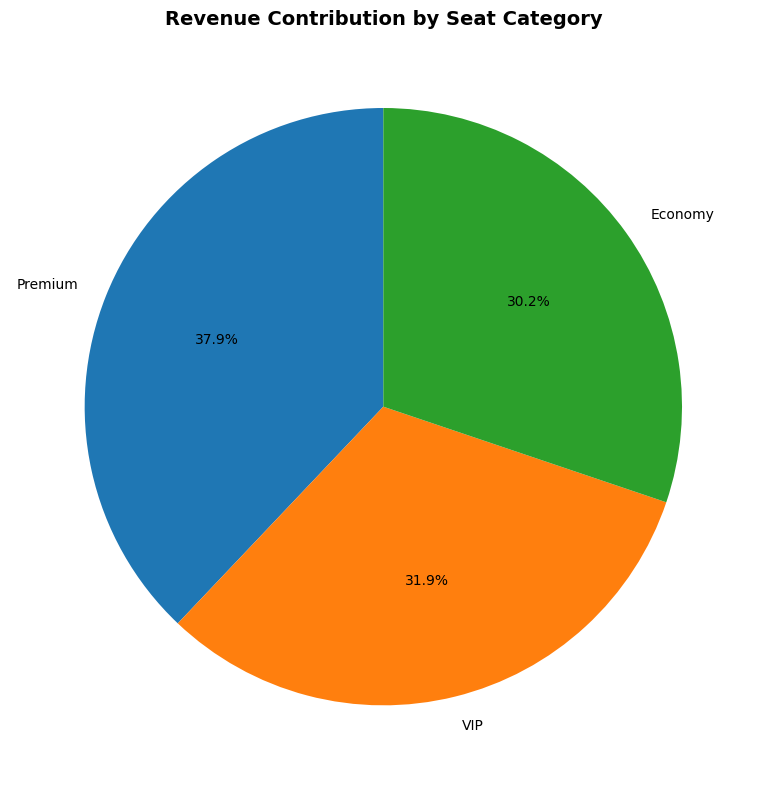

✓ revenue_by_seat_category_pie.png saved successfully


In [17]:
create_pie_chart(
    data=seat_revenue,
    title="Revenue Contribution by Seat Category",
    filename="revenue_by_seat_category_pie.png"
)

In [18]:
highest_category = seat_revenue.idxmax()

highest_revenue = seat_revenue.max()

print("Highest Revenue Category :", highest_category)

print("Revenue Generated : ₹{:,.0f}".format(highest_revenue))

Highest Revenue Category : Premium
Revenue Generated : ₹153,212,000


### Business Insight

- Premium seating categories contribute significantly more revenue because of their higher ticket prices.
- Economy seating generates a large booking volume but lower revenue per ticket.
- Revenue is concentrated among higher-priced seating categories.

## Query 2

### Business Question

Which match type generates the highest revenue?

### Objective

To compare revenue generated by different match types and identify the most profitable fixtures.

In [19]:
match_type_revenue = (
    sales_data
    .groupby("Match_Type")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(match_type_revenue)

Match_Type
League         381760800
Final            5631600
Qualifier 2      5581000
Qualifier 1      5577800
Eliminator       5484800
Name: Total_Amount, dtype: int64

In [20]:
match_type_percentage = (
    match_type_revenue
    / match_type_revenue.sum()
    *100
).round(2)

display(match_type_percentage)

Match_Type
League         94.49
Final           1.39
Qualifier 2     1.38
Qualifier 1     1.38
Eliminator      1.36
Name: Total_Amount, dtype: float64

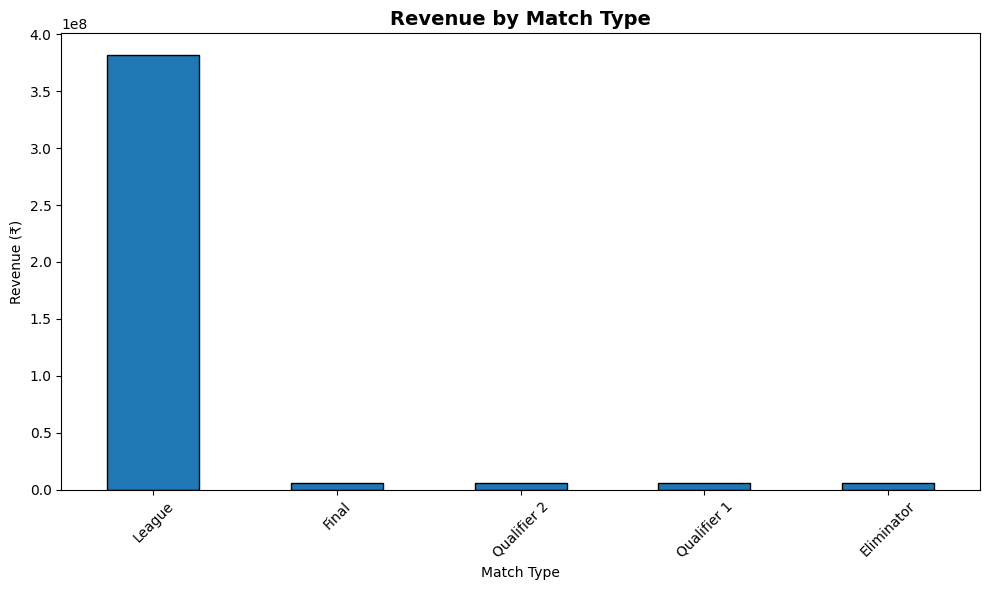

match_type_revenue_bar.png saved successfully.


In [21]:
create_bar_chart(
    data=match_type_revenue,
    title="Revenue by Match Type",
    xlabel="Match Type",
    ylabel="Revenue (₹)",
    filename="match_type_revenue_bar.png"
)

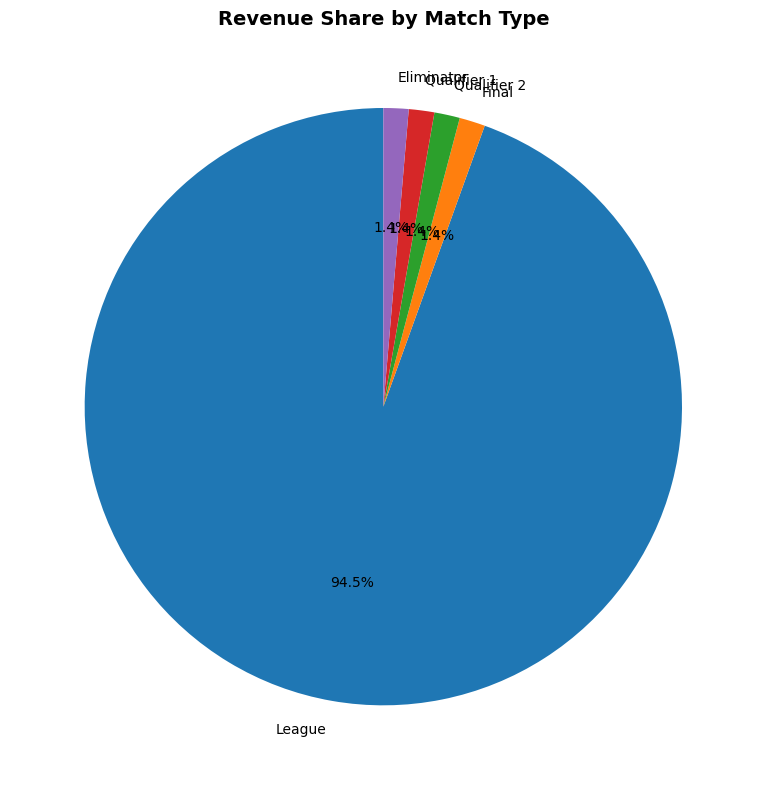

✓ match_type_revenue_pie.png saved successfully


In [22]:
create_pie_chart(
    data=match_type_revenue,
    title="Revenue Share by Match Type",
    filename="match_type_revenue_pie.png"
)

In [23]:
highest_match = match_type_revenue.idxmax()

highest_value = match_type_revenue.max()

print("Highest Revenue Match Type :", highest_match)

print("Revenue : ₹{:,.0f}".format(highest_value))

Highest Revenue Match Type : League
Revenue : ₹381,760,800


### Business Insight

- High-profile match types generally generate higher ticket revenue because of stronger fan demand.
- Revenue distribution helps prioritize premium pricing strategies for marquee fixtures.

## Query 3

### Business Question

Which venues generate the highest ticket revenue?

### Objective

To identify the most profitable IPL venues based on total ticket revenue.

In [24]:
venue_revenue = (
    sales_data
    .groupby("Venue")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(venue_revenue)

Venue
Rajiv Gandhi International Stadium    49142400
Sawai Mansingh Stadium                48944000
Narendra Modi Stadium                 44540600
M. Chinnaswamy Stadium                43767400
Arun Jaitley Stadium                  43766800
M. A. Chidambaram Stadium             43752200
Punjab Cricket Association Stadium    38114400
BRSABV Ekana Stadium                  37777800
Wankhede Stadium                      32522800
Eden Gardens                          21707600
Name: Total_Amount, dtype: int64

In [25]:
venue_revenue_percentage = (
    venue_revenue
    / venue_revenue.sum()
    *100
).round(2)

display(venue_revenue_percentage)

Venue
Rajiv Gandhi International Stadium    12.16
Sawai Mansingh Stadium                12.11
Narendra Modi Stadium                 11.02
M. Chinnaswamy Stadium                10.83
Arun Jaitley Stadium                  10.83
M. A. Chidambaram Stadium             10.83
Punjab Cricket Association Stadium     9.43
BRSABV Ekana Stadium                   9.35
Wankhede Stadium                       8.05
Eden Gardens                           5.37
Name: Total_Amount, dtype: float64

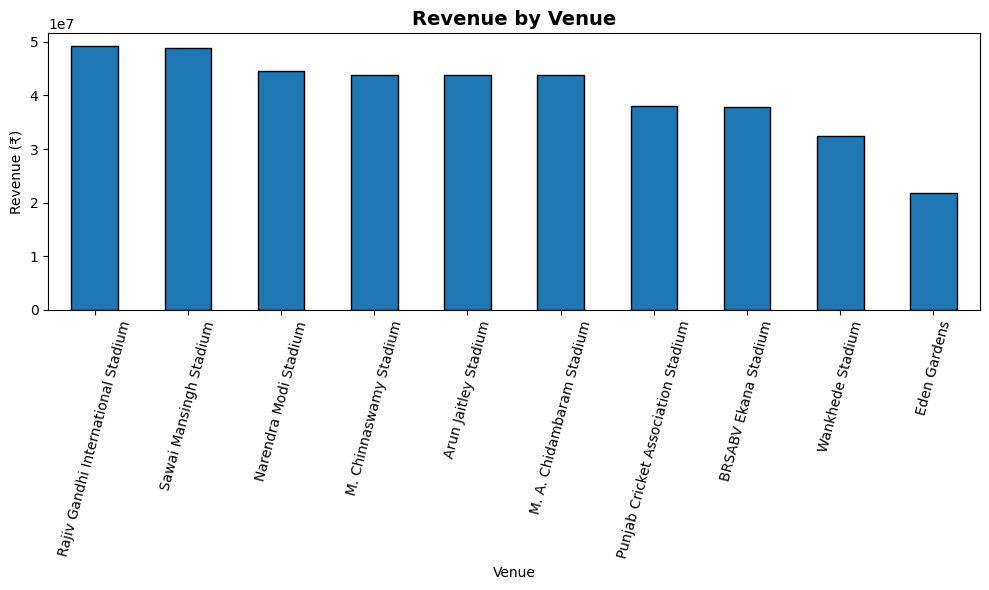

venue_revenue_bar.png saved successfully.


In [26]:
create_bar_chart(
    data=venue_revenue,
    title="Revenue by Venue",
    xlabel="Venue",
    ylabel="Revenue (₹)",
    filename="venue_revenue_bar.png",
    rotation=75
)

In [27]:
highest_venue = venue_revenue.idxmax()

highest_venue_revenue = venue_revenue.max()

print("Highest Revenue Venue :", highest_venue)

print(f"Revenue : ₹{highest_venue_revenue:,.0f}")

Highest Revenue Venue : Rajiv Gandhi International Stadium
Revenue : ₹49,142,400


### Business Insight

- A small number of venues contribute a significant portion of total ticket revenue.
- High-performing venues typically host high-demand matches and have larger seating capacities.


## Query 4

### Business Question

Which cities contribute the highest ticket revenue?

### Objective

To identify cities with the highest revenue contribution and support regional marketing strategies.

In [33]:
sales_data = (
    ticket_sales
    .merge(
        matches,
        on="Match_ID",
        how="left",
        suffixes=("", "_match")
    )
    .merge(
        customers,
        on="Customer_ID",
        how="left",
        suffixes=("", "_customer")
    )
)

display(sales_data.head())

,Ticket_ID,Customer_ID,Match_ID,Booking_Date,Seat_Category,Ticket_Price,Quantity,Total_Amount,Payment_Method,Booking_Status,Match_Date,Season,Home_Team,Away_Team,Venue,City,Match_Type,Stadium_Capacity,VIP_Capacity,Premium_Capacity,Economy_Capacity,First_Name,Last_Name,Gender,Age,Date_of_Birth,City_customer,State,Favorite_Team,Occupation,Annual_Income,Loyalty_Tier,Email,Phone,Registration_Date
0,T000001,C10477,M009,2026-03-28,Economy,800,1,800,UPI,Confirmed,2026-04-05,IPL 2026,SRH,RR,Rajiv Gandhi International Stadium,Hyderabad,League,55000,3000,12000,40000,Netra,Narang,Female,33,1993-04-02,Bengaluru,Karnataka,KKR,Nurse,329967,Bronze,netra.narang790@outlook.com,8904618696,2024-09-12
1,T000002,C11088,M039,2026-03-18,Premium,2000,1,2000,UPI,Confirmed,2026-05-05,IPL 2026,RCB,DC,M. Chinnaswamy Stadium,Bengaluru,League,40000,2500,9000,28500,Peter,Nath,Male,55,1971-11-12,Mohali,Punjab,RCB,Police Officer,467400,Silver,peter.nath759@outlook.com,7963916621,2024-06-24
2,T000003,C03583,M029,2026-04-10,Economy,800,1,800,UPI,Confirmed,2026-04-25,IPL 2026,KKR,SRH,Eden Gardens,Kolkata,League,68000,3500,15000,49500,Sanya,Grover,Female,19,2007-11-26,Bengaluru,Karnataka,SRH,Police Officer,516254,Silver,sanya.grover701@hotmail.com,6785351562,2025-03-04
3,T000004,C08929,M002,2026-03-02,Economy,800,2,1600,Debit Card,Confirmed,2026-03-29,IPL 2026,MI,RCB,Wankhede Stadium,Mumbai,League,33000,1800,7000,24200,Wriddhish,Rajagopalan,Male,36,1990-08-18,Hyderabad,Telangana,MI,Chartered Accountant,2192494,Silver,wriddhish.rajagopalan511@outlook.com,7430869547,2024-11-30
4,T000005,C02616,M036,2026-03-18,Economy,800,1,800,UPI,Confirmed,2026-05-02,IPL 2026,GT,RR,Narendra Modi Stadium,Ahmedabad,League,132000,6000,26000,100000,Saumya,Tailor,Female,52,1974-10-10,Lucknow,Uttar Pradesh,RR,Police Officer,490251,Silver,saumya.tailor783@hotmail.com,7739250144,2025-01-22


In [34]:
city_revenue = (
    sales_data
    .groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(city_revenue)

City
Hyderabad    49142400
Jaipur       48944000
Ahmedabad    44540600
Bengaluru    43767400
Delhi        43766800
Chennai      43752200
Mohali       38114400
Lucknow      37777800
Mumbai       32522800
Kolkata      21707600
Name: Total_Amount, dtype: int64

In [35]:
city_revenue_percentage = (
    city_revenue
    / city_revenue.sum()
    *100
).round(2)

display(city_revenue_percentage)

City
Hyderabad    12.16
Jaipur       12.11
Ahmedabad    11.02
Bengaluru    10.83
Delhi        10.83
Chennai      10.83
Mohali        9.43
Lucknow       9.35
Mumbai        8.05
Kolkata       5.37
Name: Total_Amount, dtype: float64

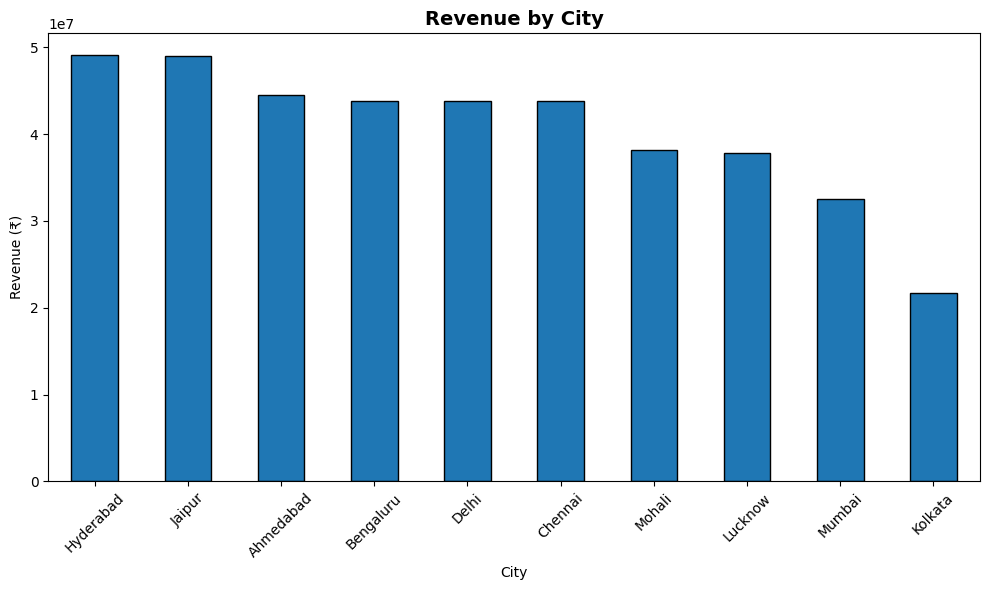

city_revenue_bar.png saved successfully.


In [36]:
create_bar_chart(
    data=city_revenue,
    title="Revenue by City",
    xlabel="City",
    ylabel="Revenue (₹)",
    filename="city_revenue_bar.png"
)

In [37]:
highest_city = city_revenue.idxmax()

highest_city_revenue = city_revenue.max()

print("Highest Revenue City :", highest_city)

print(f"Revenue : ₹{highest_city_revenue:,.0f}")

Highest Revenue City : Hyderabad
Revenue : ₹49,142,400


### Business Insight

- Cities with stronger fan engagement contribute significantly more ticket revenue.
- Revenue concentration can help identify priority markets for promotional campaigns.

### Recommendation

- Focus marketing efforts and fan engagement activities in high-revenue cities while exploring opportunities to grow ticket sales in lower-performing markets.

## Query 5

### Business Question

Which payment methods generate the highest ticket revenue?

### Objective

To understand customer payment preferences and identify payment channels contributing the most revenue.

In [38]:
payment_revenue = (
    sales_data
    .groupby("Payment_Method")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(payment_revenue)

Payment_Method
UPI            181487800
Credit Card    102260600
Debit Card      80460400
Net Banking     39827200
Name: Total_Amount, dtype: int64

In [39]:
payment_revenue_percentage = (
    payment_revenue
    / payment_revenue.sum()
    *100
).round(2)

display(payment_revenue_percentage)

Payment_Method
UPI            44.92
Credit Card    25.31
Debit Card     19.91
Net Banking     9.86
Name: Total_Amount, dtype: float64

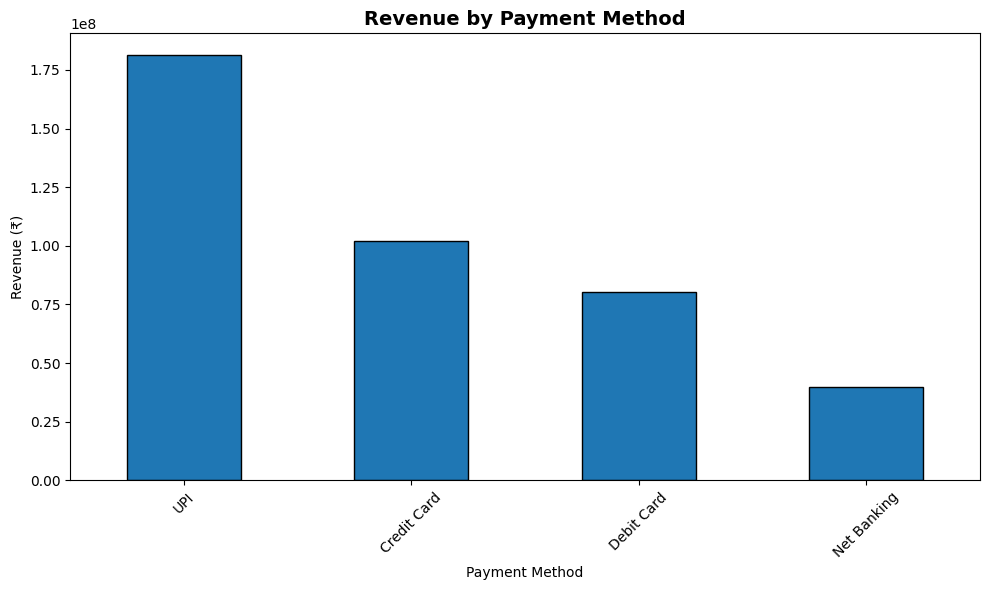

payment_method_revenue_bar.png saved successfully.


In [40]:
create_bar_chart(
    data=payment_revenue,
    title="Revenue by Payment Method",
    xlabel="Payment Method",
    ylabel="Revenue (₹)",
    filename="payment_method_revenue_bar.png"
)

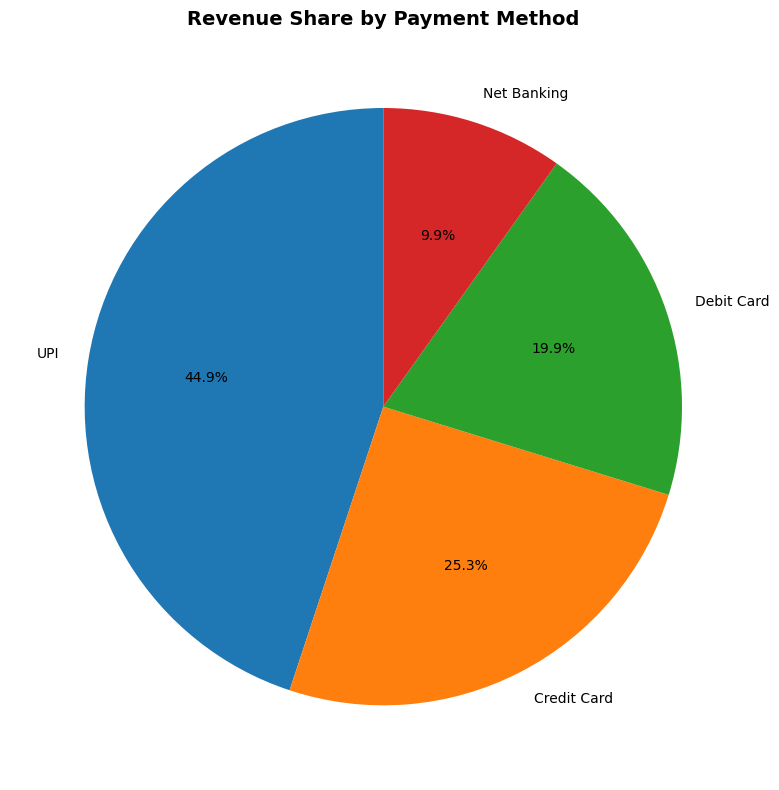

✓ payment_method_revenue_pie.png saved successfully


In [41]:
create_pie_chart(
    data=payment_revenue,
    title="Revenue Share by Payment Method",
    filename="payment_method_revenue_pie.png"
)

In [42]:
highest_payment = payment_revenue.idxmax()

highest_payment_revenue = payment_revenue.max()

print("Highest Revenue Payment Method :", highest_payment)

print(f"Revenue : ₹{highest_payment_revenue:,.0f}")

Highest Revenue Payment Method : UPI
Revenue : ₹181,487,800


### Business Insight

- Digital payment methods contribute a significant share of ticket revenue, reflecting customer preference for convenient and secure transactions.
- Understanding payment trends supports payment gateway optimization and promotional planning.

### Recommendation

- Strengthen partnerships with popular payment providers and introduce payment-specific offers to improve customer experience and maximize revenue.

# Module 2 : Customer Behaviour Analysis

## Query 6

### Business Question

Which loyalty tier generates the highest revenue?

### Objective

To identify the customer loyalty segment contributing the most revenue and understand spending behavior across different membership tiers.

In [43]:
loyalty_revenue = (
    sales_data
    .groupby("Loyalty_Tier")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(loyalty_revenue)

Loyalty_Tier
Bronze      204670000
Silver      118522200
Gold         61143000
Platinum     19700800
Name: Total_Amount, dtype: int64

In [44]:
loyalty_percentage = (
    loyalty_revenue
    / loyalty_revenue.sum()
    * 100
).round(2)

display(loyalty_percentage)

Loyalty_Tier
Bronze      50.66
Silver      29.33
Gold        15.13
Platinum     4.88
Name: Total_Amount, dtype: float64

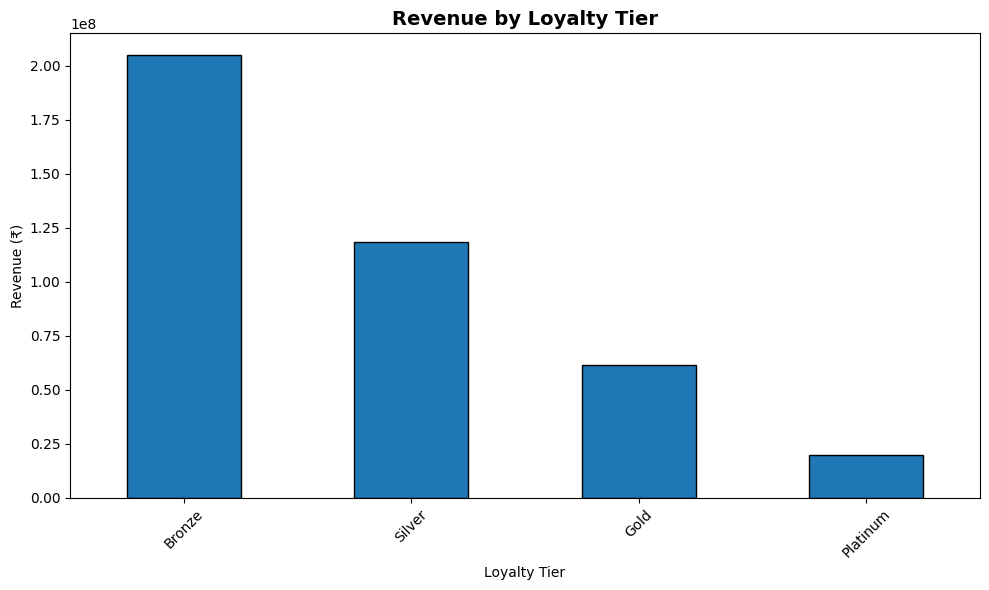

loyalty_revenue_bar.png saved successfully.


In [45]:
create_bar_chart(
    data=loyalty_revenue,
    title="Revenue by Loyalty Tier",
    xlabel="Loyalty Tier",
    ylabel="Revenue (₹)",
    filename="loyalty_revenue_bar.png"
)

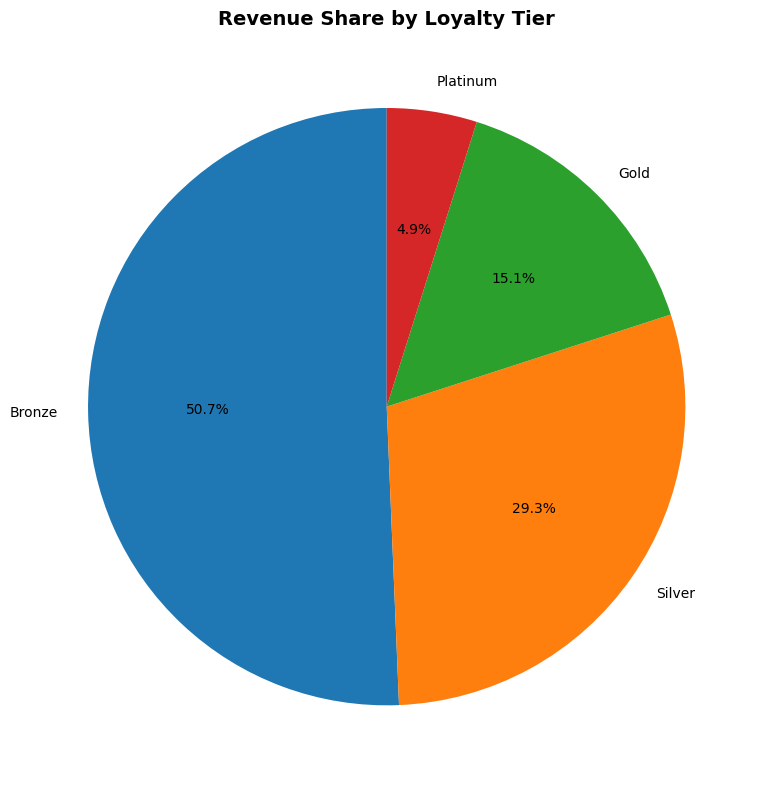

✓ loyalty_revenue_pie.png saved successfully


In [46]:
create_pie_chart(
    data=loyalty_revenue,
    title="Revenue Share by Loyalty Tier",
    filename="loyalty_revenue_pie.png"
)

In [47]:
highest_loyalty = loyalty_revenue.idxmax()

highest_revenue = loyalty_revenue.max()

print("Highest Revenue Loyalty Tier :", highest_loyalty)
print(f"Revenue : ₹{highest_revenue:,.0f}")

Highest Revenue Loyalty Tier : Bronze
Revenue : ₹204,670,000


### Business Insight

- Higher loyalty tiers generally contribute greater revenue because of increased customer engagement and repeat purchases.
- Loyalty programs play a significant role in customer retention and revenue generation.

### Recommendation

- Introduce exclusive rewards and targeted promotions to encourage Bronze customers to upgrade into higher loyalty tiers.

## Query 7

### Business Question

Which age group contributes the highest ticket revenue?

### Objective

To identify the most valuable customer age segment for targeted marketing and promotional strategies.

In [49]:
sales_data["Age_Group"] = pd.cut(
    sales_data["Age"],
    bins=[0,18,25,35,45,60,100],
    labels=[
        "Below 18",
        "19-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [50]:
age_revenue = (
    sales_data
    .groupby("Age_Group")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(age_revenue)

C:\Users\venka\AppData\Local\Temp\ipykernel_7740\3609896236.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Age_Group")["Total_Amount"]


Age_Group
26-35       136921000
19-25       100989000
36-45        92543600
46-60        58073400
Below 18     15509000
60+                 0
Name: Total_Amount, dtype: int64

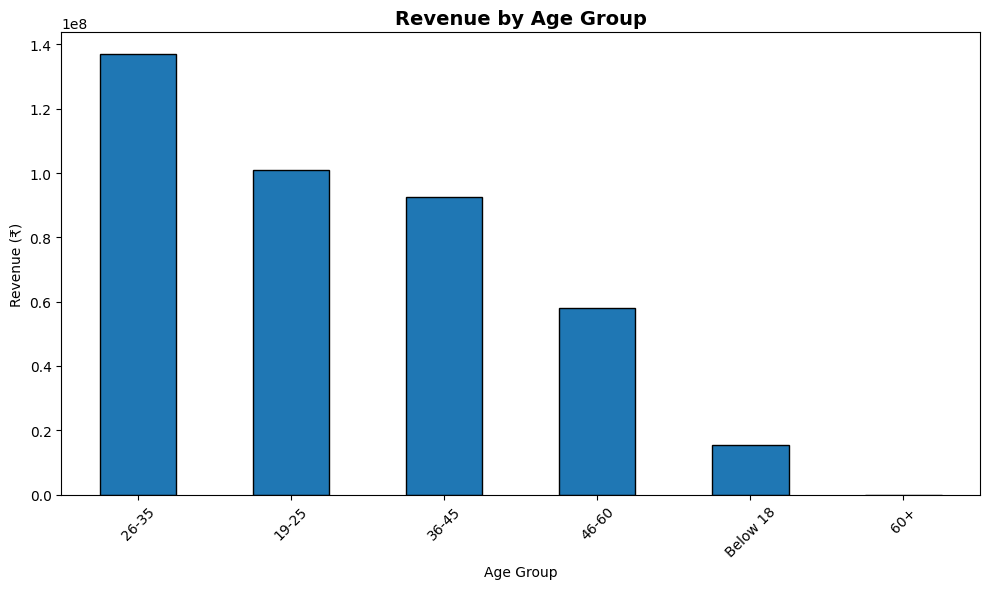

age_group_revenue_bar.png saved successfully.


In [51]:
create_bar_chart(
    data=age_revenue,
    title="Revenue by Age Group",
    xlabel="Age Group",
    ylabel="Revenue (₹)",
    filename="age_group_revenue_bar.png"
)

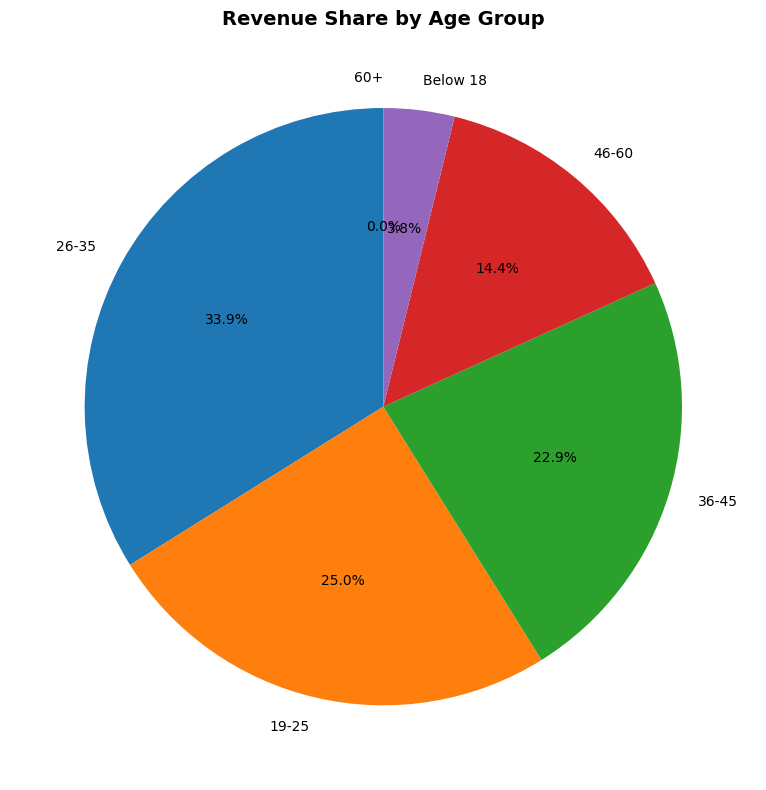

✓ age_group_revenue_pie.png saved successfully


In [52]:
create_pie_chart(
    data=age_revenue,
    title="Revenue Share by Age Group",
    filename="age_group_revenue_pie.png"
)

### Business Insight

- Certain age groups contribute significantly more revenue than others.
- Identifying the highest-spending age segment enables more focused marketing campaigns and customer engagement strategies.

### Recommendation

- Develop personalized campaigns and promotional offers tailored to the highest-value age groups while creating engagement initiatives for underrepresented segments.

## Query 8

### Business Question

How does ticket revenue vary by customer gender?

### Objective

To compare revenue contribution across customer genders and identify differences in purchasing behavior.

In [53]:
gender_revenue = (
    sales_data
    .groupby("Gender")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(gender_revenue)

Gender
Male      260967800
Female    143068200
Name: Total_Amount, dtype: int64

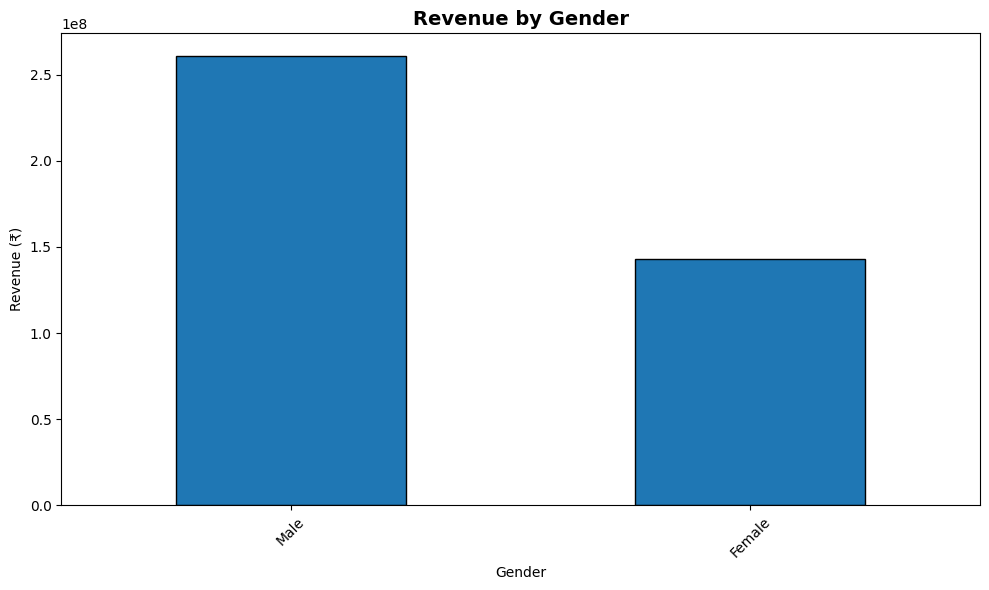

gender_revenue_bar.png saved successfully.


In [54]:
create_bar_chart(
    data=gender_revenue,
    title="Revenue by Gender",
    xlabel="Gender",
    ylabel="Revenue (₹)",
    filename="gender_revenue_bar.png"
)

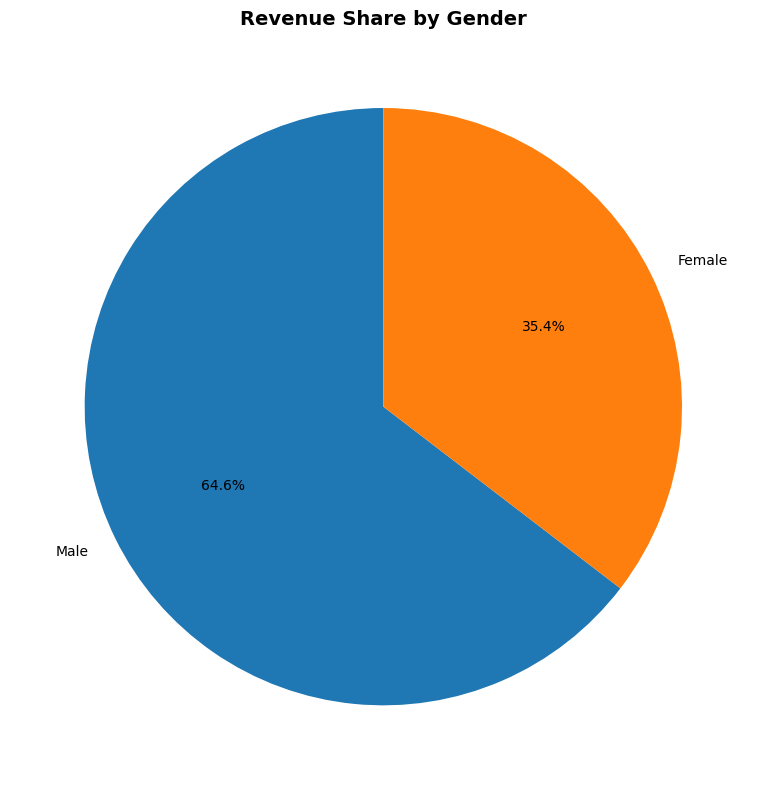

✓ gender_revenue_pie.png saved successfully


In [55]:
create_pie_chart(
    data=gender_revenue,
    title="Revenue Share by Gender",
    filename="gender_revenue_pie.png"
)

### Business Insight

- Revenue contribution varies across customer genders, providing insights into audience participation and purchasing trends.
- Understanding these patterns supports inclusive marketing and promotional planning.

### Recommendation

- Design balanced marketing campaigns that appeal to all customer groups while strengthening engagement with underrepresented segments.

## Query 9

### Business Question

Which IPL team's fans generate the highest ticket revenue?

### Objective

To identify which team's supporters contribute the highest revenue and understand fan purchasing behavior across franchises.

In [57]:
favorite_team_revenue = (
    sales_data
    .groupby("Favorite_Team")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(favorite_team_revenue)

Favorite_Team
RCB     57582600
MI      56112400
CSK     55944200
KKR     48737200
SRH     40040800
RR      32830200
DC      31834000
LSG     29796600
GT      27754000
PBKS    23404000
Name: Total_Amount, dtype: int64

In [58]:
favorite_team_percentage = (
    favorite_team_revenue
    / favorite_team_revenue.sum()
    * 100
).round(2)

display(favorite_team_percentage)

Favorite_Team
RCB     14.25
MI      13.89
CSK     13.85
KKR     12.06
SRH      9.91
RR       8.13
DC       7.88
LSG      7.37
GT       6.87
PBKS     5.79
Name: Total_Amount, dtype: float64

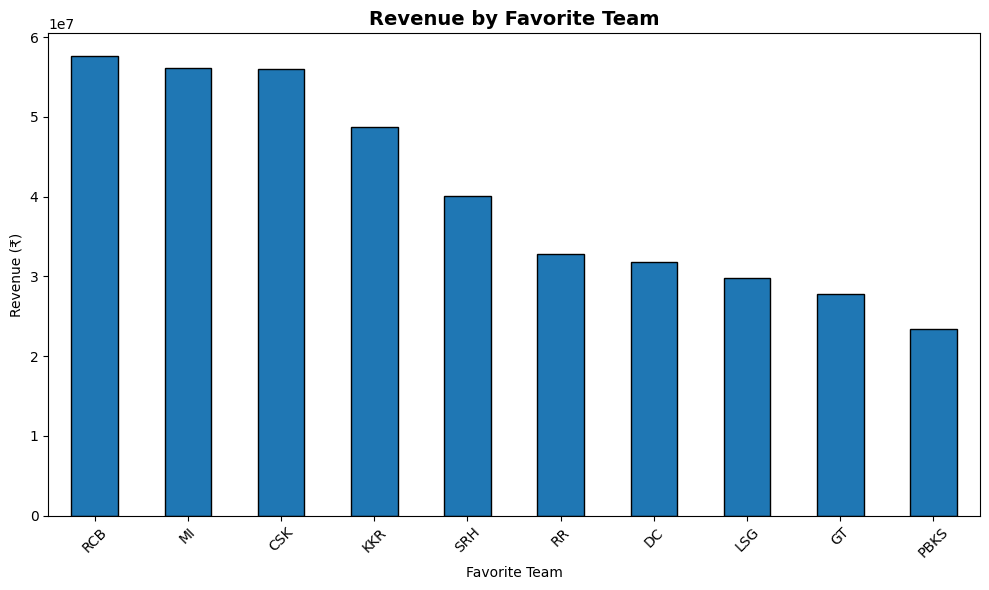

favorite_team_revenue_bar.png saved successfully.


In [59]:
create_bar_chart(
    data=favorite_team_revenue,
    title="Revenue by Favorite Team",
    xlabel="Favorite Team",
    ylabel="Revenue (₹)",
    filename="favorite_team_revenue_bar.png"
)

In [60]:
highest_team = favorite_team_revenue.idxmax()

highest_team_revenue = favorite_team_revenue.max()

print("Highest Revenue Generating Fan Base :", highest_team)

print(f"Revenue : ₹{highest_team_revenue:,.0f}")

Highest Revenue Generating Fan Base : RCB
Revenue : ₹57,582,600


### Business Insight

- Fans of certain IPL franchises contribute significantly higher ticket revenue than others.
- Team popularity has a direct impact on ticket demand and overall revenue generation.
- Understanding fan spending patterns supports franchise-specific marketing initiatives.

### Recommendation

- Introduce team-specific promotions, merchandise bundles, and exclusive fan experiences for franchises with high-spending supporters to maximize customer engagement and revenue.

## Query 10

### Business Question

Which customer occupations generate the highest ticket revenue?

### Objective

To identify professional segments with the highest spending capacity and support customer segmentation strategies.

In [61]:
occupation_revenue = (
    sales_data
    .groupby("Occupation")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(occupation_revenue)

Occupation
Chartered Accountant    21482400
Freelancer              21368000
Software Engineer       21227800
Marketing Executive     20694600
Business Owner          20596200
Student                 20594000
Data Analyst            20455400
Government Employee     20442800
Entrepreneur            20319800
Data Scientist          20158400
Doctor                  20129000
Graphic Designer        20082600
Sales Executive         19931800
Police Officer          19880200
Mechanical Engineer     19799600
Nurse                   19683600
Lawyer                  19497400
Teacher                 19461400
Banker                  19186200
Civil Engineer          19044800
Name: Total_Amount, dtype: int64

In [62]:
top_10_occupation_revenue = occupation_revenue.head(10)

display(top_10_occupation_revenue)

Occupation
Chartered Accountant    21482400
Freelancer              21368000
Software Engineer       21227800
Marketing Executive     20694600
Business Owner          20596200
Student                 20594000
Data Analyst            20455400
Government Employee     20442800
Entrepreneur            20319800
Data Scientist          20158400
Name: Total_Amount, dtype: int64

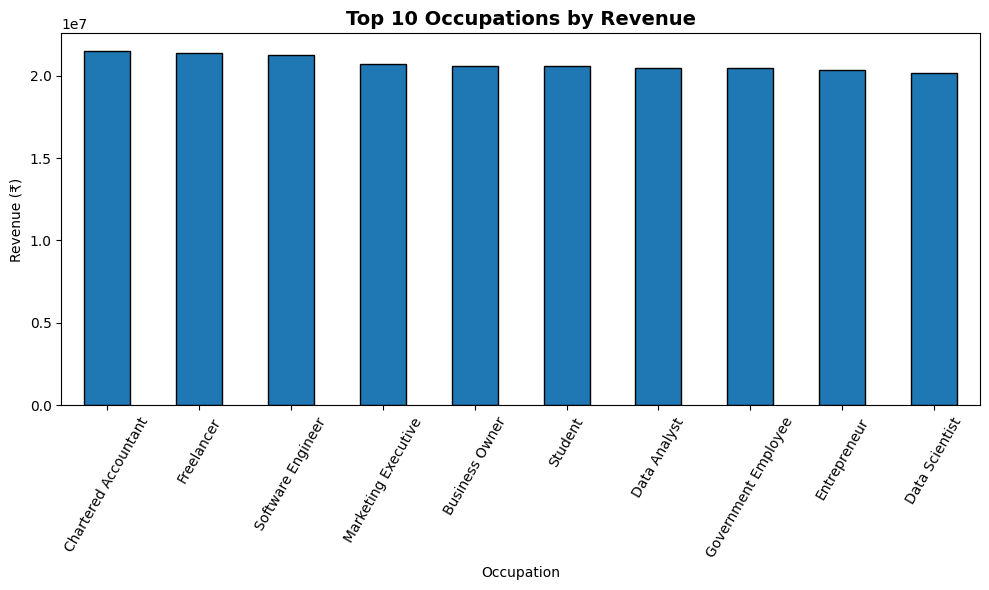

occupation_revenue_bar.png saved successfully.


In [63]:
create_bar_chart(
    data=top_10_occupation_revenue,
    title="Top 10 Occupations by Revenue",
    xlabel="Occupation",
    ylabel="Revenue (₹)",
    filename="occupation_revenue_bar.png",
    rotation=60
)

In [64]:
highest_occupation = occupation_revenue.idxmax()

highest_occupation_revenue = occupation_revenue.max()

print("Highest Revenue Generating Occupation :", highest_occupation)

print(f"Revenue : ₹{highest_occupation_revenue:,.0f}")

Highest Revenue Generating Occupation : Chartered Accountant
Revenue : ₹21,482,400
